<a href="https://colab.research.google.com/github/weagan/Diffusion/blob/main/text_conditioned_shape_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text-Conditioned Shape Diffusion — v3
## Fixing shape confusion with hybrid conditioning

### What went wrong in v2
The U-Net learned colour perfectly but confused shapes ~50% of the time.
Root cause: CLIP's text embeddings for "circle", "square", "triangle" are
**geometrically similar** in embedding space — CLIP wasn't trained to separate them.
Cross-attention over a 512-d vector that barely distinguishes shape words can't
reliably steer the denoiser.

### What v3 does differently
| | v2 | v3 |
|---|---|---|
| Shape encoding | CLIP text emb (weak shape signal) | **Learned shape embedding** (orthogonal by construction) |
| Colour encoding | CLIP text emb | **Learned colour embedding** (orthogonal by construction) |
| Conditioning fusion | single cross-attention on 512-d vec | cross-attn on shape + colour **separately**, then concatenated |
| Training samples | 1,500 / class | **5,000 / class** |
| Epochs | 50 | **150** with warmup + cosine decay |
| CFG dropout | 15% | 20%, applied independently to shape & colour |

**Diffusion math: still identical.** Only the conditioning pathway changes.

### Architecture
```
Prompt "red circle"
        │
   ┌────┴─────┐
   ▼          ▼
shape_idx=0  colour_idx=0
   │          │
nn.Embedding  nn.Embedding   ← learned, not CLIP
(3 shapes,    (5 colours,
  128-d)        128-d)
   │          │
   └────┬─────┘
        ▼
   concat → 256-d conditioning vector
        │
   cross-attention at every U-Net level
        │
   predicted ε  (1×64×64)
```


## 0 · Environment

In [ ]:
import os, math, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# ── Secrets (Colab / Kaggle) — optional, not needed for this notebook ─────────
for _loader in [
    lambda: __import__('google.colab', fromlist=['userdata']).userdata.get('HF_TOKEN'),
    lambda: __import__('kaggle_secrets', fromlist=['UserSecretsClient']).UserSecretsClient().get_secret('HF_TOKEN'),
]:
    try: os.environ.setdefault('HF_TOKEN', _loader()); break
    except: pass

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f'Device: {device}  |  GPUs: {num_gpus}')

IMG_SIZE = 64


Device: cuda  |  GPUs: 2


## 1 · Class maps — shape & colour indices

In [ ]:
SHAPES  = ['circle', 'square', 'triangle']
COLOURS = ['red', 'blue', 'green', 'yellow', 'purple']

SHAPE2IDX  = {s: i for i, s in enumerate(SHAPES)}
COLOUR2IDX = {c: i for i, c in enumerate(COLOURS)}

N_SHAPES  = len(SHAPES)
N_COLOURS = len(COLOURS)

# Plot colours for visualisation
VIZ_COLOUR = {
    'red':    [1.00, 0.15, 0.15],
    'blue':   [0.15, 0.45, 1.00],
    'green':  [0.15, 0.90, 0.25],
    'yellow': [1.00, 0.95, 0.10],
    'purple': [0.65, 0.15, 0.90],
}
print('Shapes :', SHAPE2IDX)
print('Colours:', COLOUR2IDX)


Shapes : {'circle': 0, 'square': 1, 'triangle': 2}
Colours: {'red': 0, 'blue': 1, 'green': 2, 'yellow': 3, 'purple': 4}


## 2 · Dataset — 5,000 samples per (colour, shape)

Each sample stores:
- `image`       : 1×64×64 float tensor
- `shape_idx`   : int  (0=circle, 1=square, 2=triangle)
- `colour_idx`  : int  (0=red, 1=blue, 2=green, 3=yellow, 4=purple)


Dataset: torch.Size([75000, 1, 64, 64])  (3 shapes × 5 colours × 5,000)


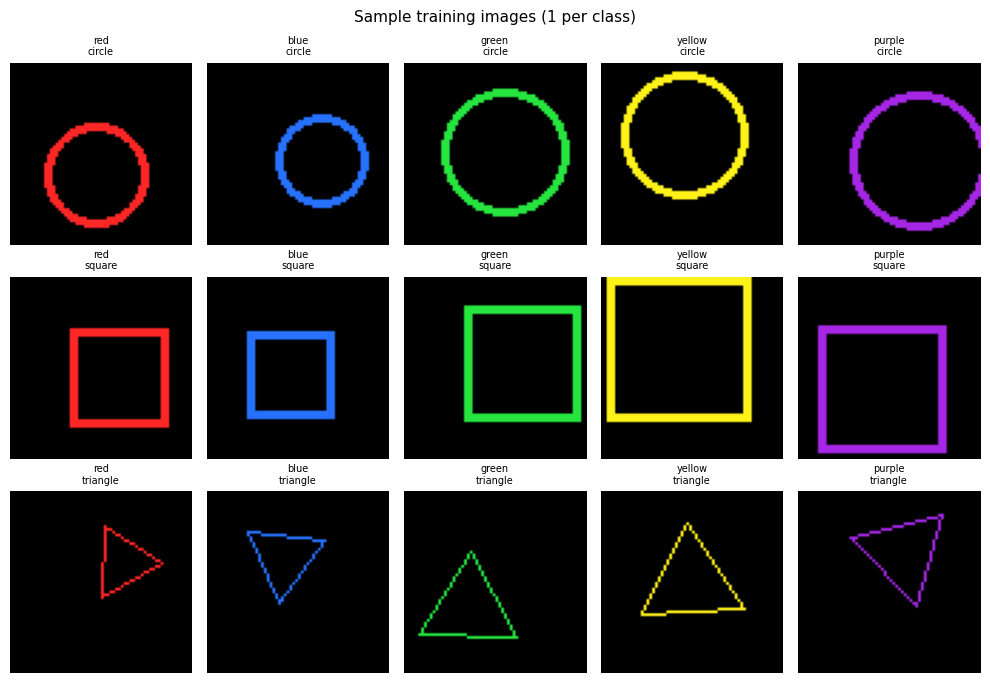

In [ ]:
IMG  = IMG_SIZE
HALF = IMG // 2

def render_circle(sf, cx, cy):
    img = Image.new('L', (IMG, IMG), 0)
    d = ImageDraw.Draw(img)
    r = int(HALF * sf)
    d.ellipse([cx-r, cy-r, cx+r, cy+r], outline=255, width=3)
    return np.array(img, dtype=np.float32) / 255.0

def render_square(sf, cx, cy):
    img = Image.new('L', (IMG, IMG), 0)
    d = ImageDraw.Draw(img)
    r = int(HALF * sf)
    d.rectangle([cx-r, cy-r, cx+r, cy+r], outline=255, width=3)
    return np.array(img, dtype=np.float32) / 255.0

def render_triangle(sf, cx, cy, ang):
    img = Image.new('L', (IMG, IMG), 0)
    d = ImageDraw.Draw(img)
    r = int(HALF * sf)
    pts = [(cx + r*math.cos(ang + math.pi/2 + k*2*math.pi/3),
            cy - r*math.sin(ang + math.pi/2 + k*2*math.pi/3)) for k in range(3)]
    d.polygon(pts, outline=255)
    return np.array(img, dtype=np.float32) / 255.0

RENDER_FNS = [render_circle, render_square, render_triangle]

N_PER = 5000   # per (colour, shape) combination

all_imgs    = []
all_shapes  = []
all_colours = []

for ci, colour in enumerate(COLOURS):
    for si, shape in enumerate(SHAPES):
        fn = RENDER_FNS[si]
        for _ in range(N_PER):
            sf  = random.uniform(0.45, 0.80)
            cx  = HALF + random.randint(-10, 10)
            cy  = HALF + random.randint(-10, 10)
            ang = random.uniform(0, 2*math.pi)
            img = fn(sf, cx, cy) if shape != 'triangle' else fn(sf, cx, cy, ang)
            all_imgs.append(img)
            all_shapes.append(si)
            all_colours.append(ci)

x0_all      = torch.tensor(np.stack(all_imgs))[:, None, :, :]  # (N,1,64,64)
shapes_all  = torch.tensor(all_shapes,  dtype=torch.long)
colours_all = torch.tensor(all_colours, dtype=torch.long)

print(f'Dataset: {x0_all.shape}  ({N_SHAPES} shapes × {N_COLOURS} colours × {N_PER:,})')

# Sanity plot
fig, axes = plt.subplots(3, 5, figsize=(10, 7))
for si, shape in enumerate(SHAPES):
    for ci, colour in enumerate(COLOURS):
        idx = (ci * N_SHAPES + si) * N_PER
        tint = torch.tensor(VIZ_COLOUR[colour])
        g    = x0_all[idx, 0]
        rgb  = (g.unsqueeze(-1) * tint).numpy()
        axes[si][ci].imshow(np.clip(rgb, 0, 1))
        axes[si][ci].set_title(f'{colour}\n{shape}', fontsize=7)
        axes[si][ci].axis('off')
plt.suptitle('Sample training images (1 per class)', fontsize=11)
plt.tight_layout(); plt.show()


## 3 · Diffusion pipeline — same DDPM math as always

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$$
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\varepsilon_\theta(x_t,t,c)\right)+\sqrt{\beta_t}\,z$$


In [ ]:
class DiffusionPipeline:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T      = T
        self.device = device
        beta             = torch.linspace(beta_start, beta_end, T)
        self.beta        = beta.to(device)
        self.alpha       = (1. - beta).to(device)
        self.alpha_bar   = torch.cumprod(1. - beta, 0).to(device)

    def q_sample(self, x0, t):
        """Forward: add noise to x0 at timestep t."""
        eps = torch.randn_like(x0)
        ab  = self.alpha_bar[t].view(-1, 1, 1, 1)
        return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, eps

    @torch.no_grad()
    def p_sample_loop(self, model, shape_idx, colour_idx,
                      guidance_scale=5.0, n=1,
                      null_shape=None, null_colour=None):
        """
        Reverse: denoise from Gaussian noise with CFG.
        shape_idx, colour_idx: int scalars
        """
        model.eval()
        xt = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=self.device)

        s  = torch.full((n,), shape_idx,  device=self.device, dtype=torch.long)
        c  = torch.full((n,), colour_idx, device=self.device, dtype=torch.long)
        ns = torch.full((n,), null_shape,  device=self.device, dtype=torch.long)
        nc = torch.full((n,), null_colour, device=self.device, dtype=torch.long)

        for t in reversed(range(self.T)):
            tv     = torch.full((n,), t, device=self.device, dtype=torch.long)
            eps_c  = model(xt, tv, s, c)
            eps_u  = model(xt, tv, ns, nc)
            eps    = eps_u + guidance_scale * (eps_c - eps_u)

            a  = self.alpha[t]; ab = self.alpha_bar[t]; b = self.beta[t]
            mu = (1 / a.sqrt()) * (xt - (1 - a) / (1 - ab).sqrt() * eps)
            xt = mu + b.sqrt() * torch.randn_like(xt) if t > 0 else mu

        model.train()
        return xt   # (n,1,64,64)

pipeline = DiffusionPipeline(T=1000, device=device)
print('✓ DiffusionPipeline ready')


✓ DiffusionPipeline ready


## 4 · U-Net with learned shape + colour embeddings

### Why learned embeddings beat CLIP here

CLIP maps text to a 512-d space optimised for **image–text alignment**, not
geometric shape discrimination. "circle", "square", "triangle" land very close
together because they're semantically related.

Learned embeddings are **orthogonal by construction** — the model is free to
place them wherever is most useful for denoising. With only 3 shape classes and
5 colour classes, the embedding table is tiny but maximally expressive.

### Conditioning mechanism
```
shape_idx ──► nn.Embedding(3, 128) ──► shape_emb   (B, 128)
                                              │
                                         concat ──► cond (B, 256)
                                              │
colour_idx ──► nn.Embedding(5, 128) ──► colour_emb  (B, 128)
```
`cond` is injected at every U-Net level via **cross-attention**.


In [ ]:
class SinusoidalEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        h = self.dim // 2
        f = torch.exp(-math.log(10000) * torch.arange(h, device=t.device) / max(h-1, 1))
        x = t.float()[:, None] * f[None]
        return torch.cat([x.sin(), x.cos()], -1)

class TimeProj(nn.Module):
    def __init__(self, t_dim, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(t_dim, out_ch*2), nn.SiLU(), nn.Linear(out_ch*2, out_ch*2))
    def forward(self, t): return self.net(t)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.c1   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.c2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.n1   = nn.GroupNorm(8, out_ch)
        self.n2   = nn.GroupNorm(8, out_ch)
        self.tp   = TimeProj(t_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, te):
        h = F.silu(self.n1(self.c1(x)))
        sc, sh = self.tp(te).chunk(2, -1)
        h = h * (1 + sc[:,:,None,None]) + sh[:,:,None,None]
        return F.silu(self.n2(self.c2(h))) + self.skip(x)

class CrossAttn(nn.Module):
    """Spatial features (B,C,H,W) attend to conditioning vector (B, ctx_dim)."""
    def __init__(self, ch, ctx_dim, heads=4):
        super().__init__()
        self.norm  = nn.GroupNorm(8, ch)
        self.to_q  = nn.Linear(ch, ch)
        self.to_k  = nn.Linear(ctx_dim, ch)
        self.to_v  = nn.Linear(ctx_dim, ch)
        self.out   = nn.Linear(ch, ch)
        self.scale = ch ** -0.5
    def forward(self, x, ctx):
        B,C,H,W = x.shape
        h  = self.norm(x).reshape(B,C,H*W).transpose(1,2)   # (B,HW,C)
        c  = ctx.unsqueeze(1)                                  # (B,1,ctx)
        Q,K,V = self.to_q(h), self.to_k(c), self.to_v(c)
        a  = torch.softmax(Q @ K.transpose(1,2) * self.scale, -1)
        o  = self.out(a @ V).transpose(1,2).reshape(B,C,H,W)
        return x + o

# ── Full U-Net ────────────────────────────────────────────────────────────────
COND_DIM = 256   # 128 shape + 128 colour

class ShapeUNet(nn.Module):
    def __init__(self, n_shapes, n_colours,
                 emb_dim=128, base_ch=64, t_dim=256):
        super().__init__()
        T = t_dim
        CD = emb_dim * 2   # = COND_DIM

        # Learned embeddings — the key fix
        self.shape_emb  = nn.Embedding(n_shapes + 1,  emb_dim)   # +1 for null
        self.colour_emb = nn.Embedding(n_colours + 1, emb_dim)   # +1 for null

        self.time_emb = SinusoidalEmb(T)

        # Encoder
        self.d1 = ResBlock(1,         base_ch,   T); self.p1 = nn.AvgPool2d(2)
        self.d2 = ResBlock(base_ch,   base_ch*2, T); self.a2 = CrossAttn(base_ch*2, CD); self.p2 = nn.AvgPool2d(2)
        self.d3 = ResBlock(base_ch*2, base_ch*4, T); self.a3 = CrossAttn(base_ch*4, CD); self.p3 = nn.AvgPool2d(2)

        # Bottleneck
        self.b1 = ResBlock(base_ch*4, base_ch*4, T)
        self.ba = CrossAttn(base_ch*4, CD)
        self.b2 = ResBlock(base_ch*4, base_ch*4, T)

        # Decoder
        self.u3 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 2, 2); self.r3 = ResBlock(base_ch*8, base_ch*2, T); self.ua3 = CrossAttn(base_ch*2, CD)
        self.u2 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 2, 2); self.r2 = ResBlock(base_ch*4, base_ch,   T); self.ua2 = CrossAttn(base_ch,   CD)
        self.u1 = nn.ConvTranspose2d(base_ch,   base_ch,   2, 2); self.r1 = ResBlock(base_ch*2, base_ch,   T)

        self.out = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x, t, shape_idx, colour_idx):
        te   = self.time_emb(t)
        cond = torch.cat([self.shape_emb(shape_idx),
                          self.colour_emb(colour_idx)], dim=-1)  # (B, 256)

        s1 = self.d1(x, te)
        s2 = self.a2(self.d2(self.p1(s1), te), cond)
        s3 = self.a3(self.d3(self.p2(s2), te), cond)
        b  = self.b2(self.ba(self.b1(self.p3(s3), te), cond), te)

        d3 = self.ua3(self.r3(torch.cat([self.u3(b),  s3], 1), te), cond)
        d2 = self.ua2(self.r2(torch.cat([self.u2(d3), s2], 1), te), cond)
        d1 =          self.r1(torch.cat([self.u1(d2), s1], 1), te)
        return self.out(d1)


## 5 · Initialise model, optimiser, null tokens

In [ ]:
model = ShapeUNet(n_shapes=N_SHAPES, n_colours=N_COLOURS,
                   emb_dim=128, base_ch=64, t_dim=256).to(device)

if num_gpus > 1:
    print(f'DataParallel across {num_gpus} GPUs')
    model = nn.DataParallel(model)

# Null tokens — index N_SHAPES and N_COLOURS respectively
NULL_SHAPE  = N_SHAPES
NULL_COLOUR = N_COLOURS

optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

EPOCHS    = 40 #150
# Warmup 10 epochs → cosine decay to 0
def lr_lambda(ep):
    if ep < 10: return (ep + 1) / 10
    return 0.5 * (1 + math.cos(math.pi * (ep - 10) / (EPOCHS - 10)))
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')
print(f'Null shape token: {NULL_SHAPE}  |  Null colour token: {NULL_COLOUR}')


DataParallel across 2 GPUs
Parameters: 7,380,801
Null shape token: 3  |  Null colour token: 5


## 6 · DataLoader

In [ ]:
dataset    = TensorDataset(x0_all, shapes_all, colours_all)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True,
                        pin_memory=(device.type == 'cuda'), num_workers=0)
print(f'DataLoader: {len(dataset):,} samples, {len(dataloader)} batches/epoch')


DataLoader: 75,000 samples, 586 batches/epoch


## 7 · Training loop

$$\mathcal{L}(\theta) = \mathbb{E}_{t,x_0,\varepsilon}\!\left[\|\varepsilon - \varepsilon_\theta(x_t,t,s,c)\|^2\right]$$

**CFG training**: with probability 0.20, each of shape and colour conditioning
is independently replaced by its null token. This teaches the model to generate
both conditioned and unconditioned, enabling CFG at inference.


Training…
  Epoch 001/40  loss=0.07788  lr=4.00e-05
  Epoch 010/40  loss=0.00295  lr=2.00e-04
  Epoch 020/40  loss=0.00187  lr=1.50e-04
  Epoch 030/40  loss=0.00141  lr=5.00e-05
  Epoch 040/40  loss=0.00126  lr=0.00e+00


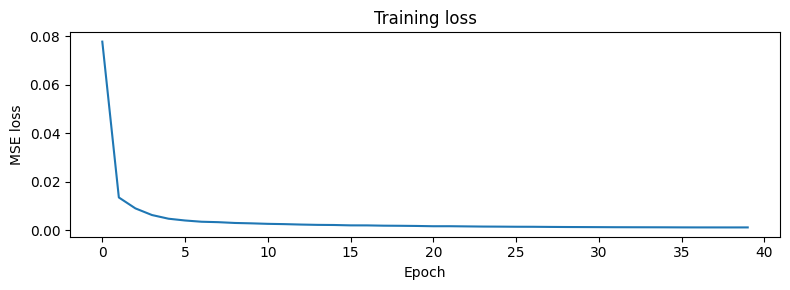

✓ Training complete.


In [ ]:
P_UNCOND = 0.20
loss_history = []
model.train()
print('Training…')

for epoch in range(EPOCHS):
    running = 0.
    for x0_b, s_b, c_b in dataloader:
        x0_b = x0_b.to(device)
        s_b  = s_b.to(device)
        c_b  = c_b.to(device)
        B    = x0_b.shape[0]

        # Independently null-out shape and colour with prob P_UNCOND
        s_b = torch.where(torch.rand(B, device=device) < P_UNCOND,
                          torch.full_like(s_b, NULL_SHAPE), s_b)
        c_b = torch.where(torch.rand(B, device=device) < P_UNCOND,
                          torch.full_like(c_b, NULL_COLOUR), c_b)

        t       = torch.randint(0, pipeline.T, (B,), device=device)
        xt, eps = pipeline.q_sample(x0_b, t)

        optimizer.zero_grad()
        loss = F.mse_loss(model(xt, t, s_b, c_b), eps)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * B

    scheduler.step()
    avg = running / len(dataset)
    loss_history.append(avg)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1:03d}/{EPOCHS}  loss={avg:.5f}  lr={scheduler.get_last_lr()[0]:.2e}')

plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title('Training loss'); plt.tight_layout(); plt.show()
print('✓ Training complete.')


## 8 · Generation helper

In [ ]:
def parse_prompt(prompt: str):
    """Extract shape_idx and colour_idx from a prompt like 'red circle'."""
    p = prompt.lower().strip()
    si = next((i for i,s in enumerate(SHAPES)  if s in p), None)
    ci = next((i for i,c in enumerate(COLOURS) if c in p), None)
    assert si is not None, f'No known shape in: {prompt!r}'
    assert ci is not None, f'No known colour in: {prompt!r}'
    return si, ci

def generate(prompt: str, guidance_scale: float = 5.0, n: int = 4):
    si, ci = parse_prompt(prompt)
    core   = model.module if num_gpus > 1 else model
    imgs   = pipeline.p_sample_loop(core, si, ci,
                                    guidance_scale=guidance_scale,
                                    n=n,
                                    null_shape=NULL_SHAPE,
                                    null_colour=NULL_COLOUR)
    imgs = imgs.cpu().float()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min() + 1e-8)
    tint = torch.tensor(VIZ_COLOUR[COLOURS[ci]])

    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1: axes = [axes]
    for ax, img in zip(axes, imgs):
        rgb = img[0].unsqueeze(-1) * tint
        ax.imshow(rgb.clamp(0,1).numpy()); ax.axis('off')
    fig.suptitle(f'"{prompt}"  cfg={guidance_scale}', fontsize=11)
    plt.tight_layout(); plt.show()
    return imgs


## 9 · Headline test — "red circle", "blue square", "green triangle"

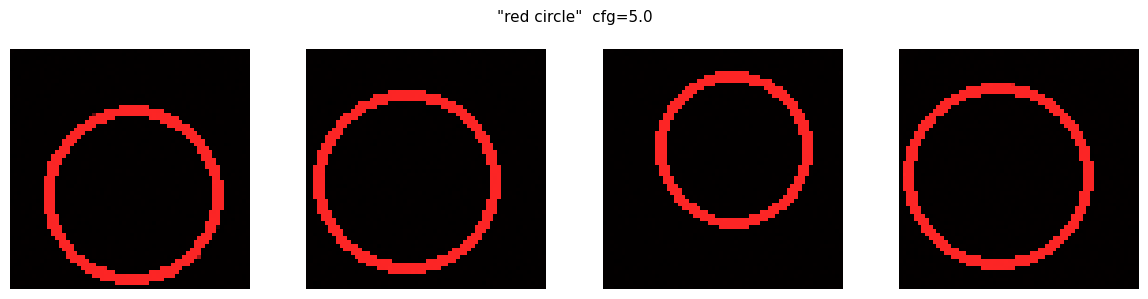

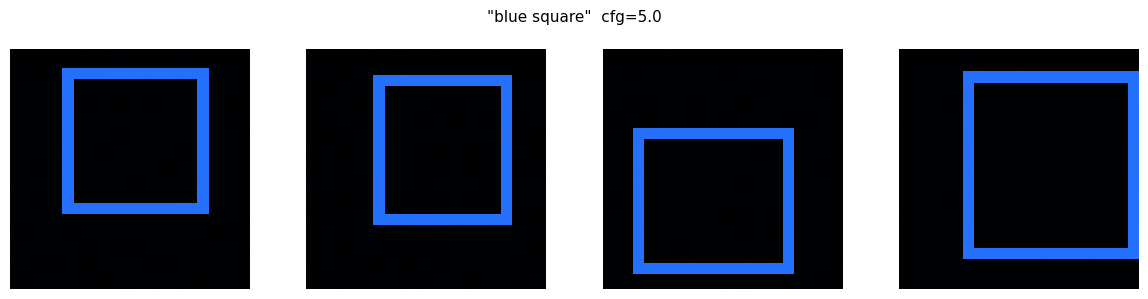

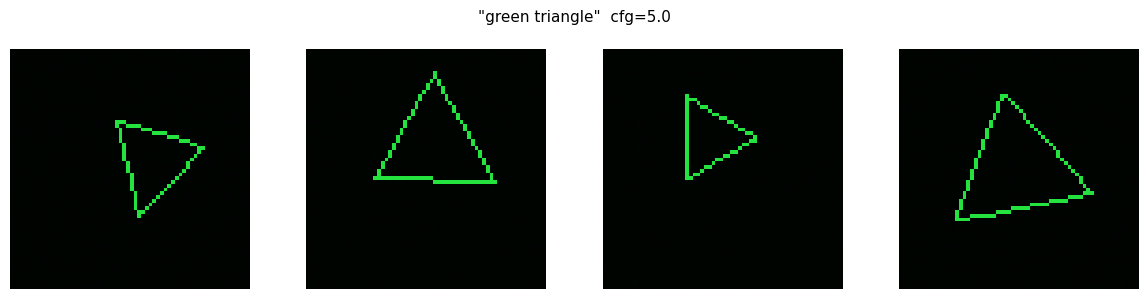

In [ ]:
for prompt in ['red circle', 'blue square', 'green triangle']:
    _ = generate(prompt, guidance_scale=5.0, n=4)


## 10 · Full 5-colour × 3-shape grid

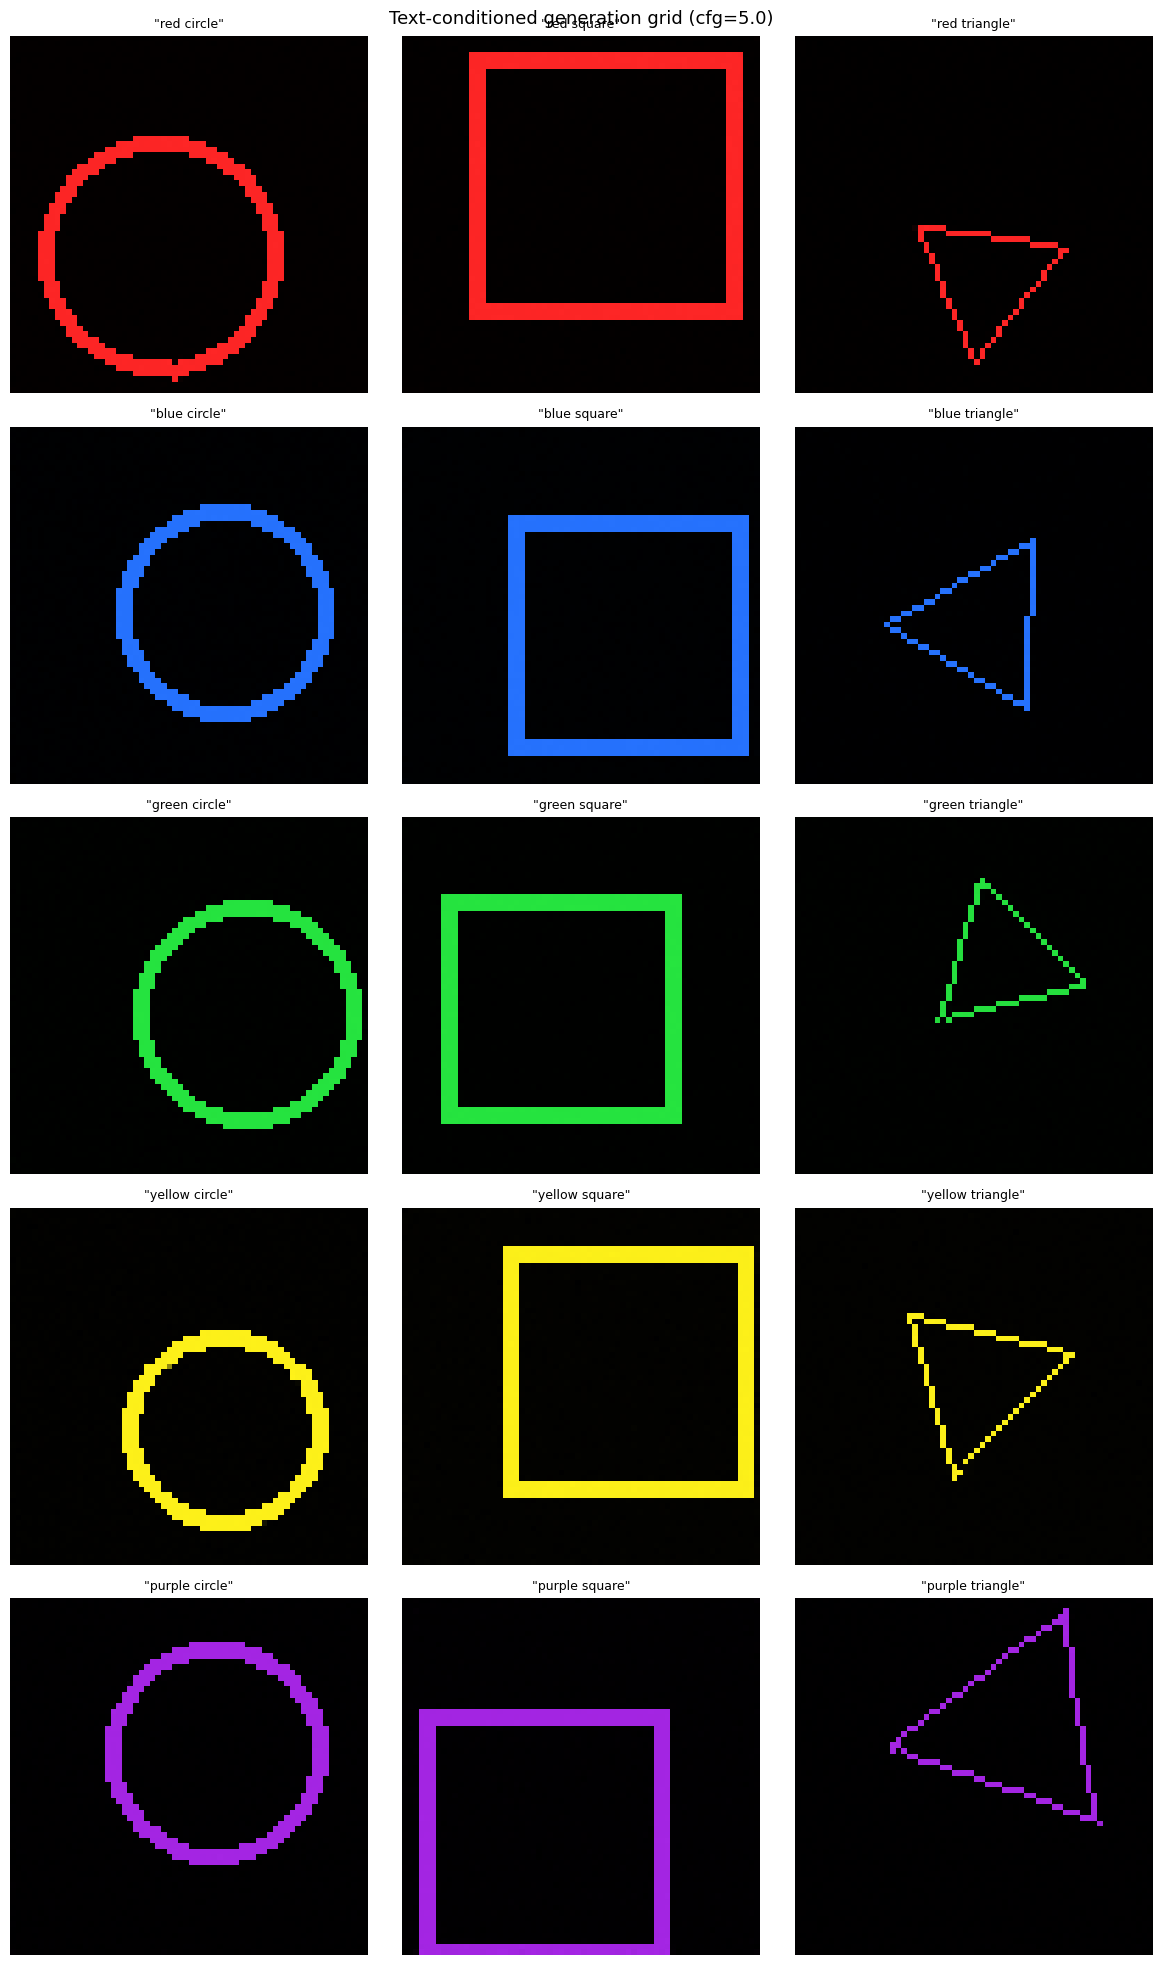

✓ Grid complete.


In [ ]:
core = model.module if num_gpus > 1 else model
fig, axes = plt.subplots(N_COLOURS, N_SHAPES,
                         figsize=(4*N_SHAPES, 4*N_COLOURS))
fig.suptitle('Text-conditioned generation grid (cfg=5.0)', fontsize=13)

for ci, colour in enumerate(COLOURS):
    for si, shape in enumerate(SHAPES):
        imgs = pipeline.p_sample_loop(core, si, ci,
                                      guidance_scale=5.0,
                                      n=1,
                                      null_shape=NULL_SHAPE,
                                      null_colour=NULL_COLOUR)
        imgs = imgs.cpu().float()
        imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min() + 1e-8)
        tint = torch.tensor(VIZ_COLOUR[colour])
        rgb  = imgs[0,0].unsqueeze(-1) * tint

        ax = axes[ci][si]
        ax.imshow(rgb.clamp(0,1).numpy())
        ax.set_title(f'"{colour} {shape}"', fontsize=9)
        ax.axis('off')

plt.tight_layout(); plt.show()
print('✓ Grid complete.')


## 11 · CFG guidance scale ablation — 'blue square'

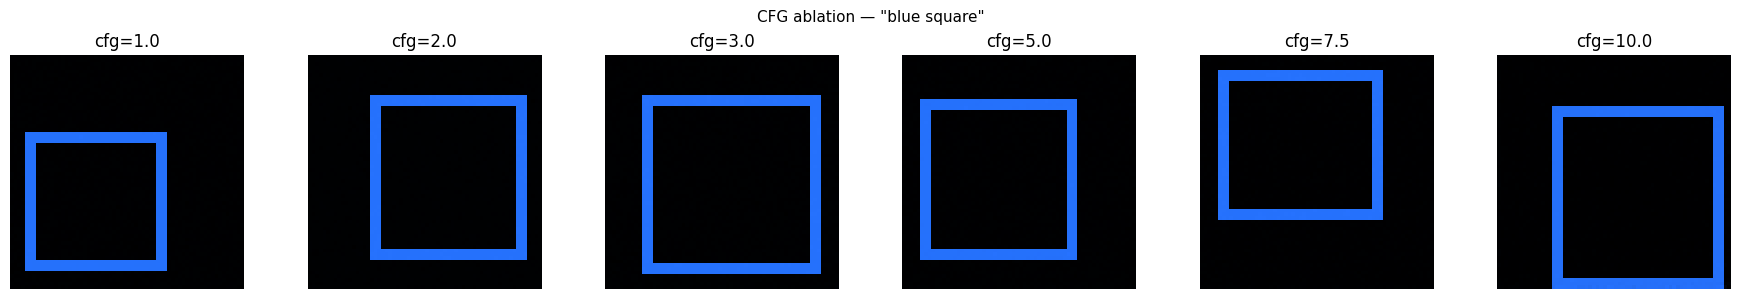

In [ ]:
core   = model.module if num_gpus > 1 else model
scales = [1.0, 2.0, 3.0, 5.0, 7.5, 10.0]
si, ci = SHAPE2IDX['square'], COLOUR2IDX['blue']
tint   = torch.tensor(VIZ_COLOUR['blue'])

fig, axes = plt.subplots(1, len(scales), figsize=(3*len(scales), 3))
fig.suptitle('CFG ablation — "blue square"', fontsize=11)
for ax, gs in zip(axes, scales):
    img = pipeline.p_sample_loop(core, si, ci,
                                 guidance_scale=gs, n=1,
                                 null_shape=NULL_SHAPE, null_colour=NULL_COLOUR)
    img = img.cpu().float()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = img[0,0].unsqueeze(-1) * tint
    ax.imshow(rgb.clamp(0,1).numpy()); ax.set_title(f'cfg={gs}'); ax.axis('off')
plt.tight_layout(); plt.show()


## 12 · Denoising strip — noise → "red circle"

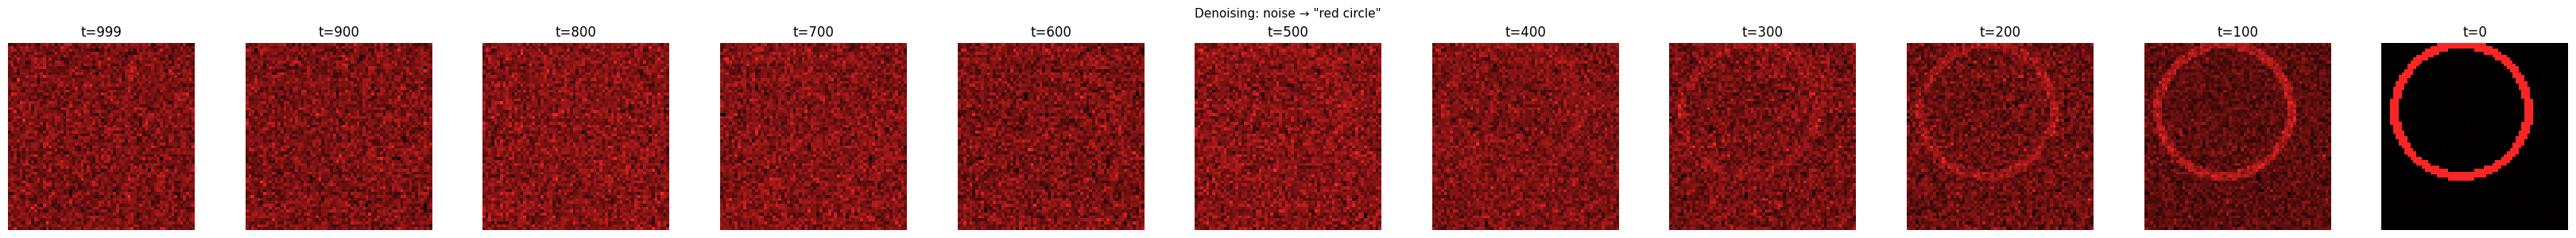

In [ ]:
@torch.no_grad()
def denoise_strip(model, shape_idx, colour_idx,
                  guidance_scale=5.0, capture_every=100):
    core = model.module if num_gpus > 1 else model
    core.eval()
    xt  = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=device)
    s   = torch.tensor([shape_idx],  device=device)
    c   = torch.tensor([colour_idx], device=device)
    ns  = torch.tensor([NULL_SHAPE],  device=device)
    nc  = torch.tensor([NULL_COLOUR], device=device)
    steps = []
    for t in reversed(range(pipeline.T)):
        tv  = torch.tensor([t], device=device)
        ec  = core(xt, tv, s, c)
        eu  = core(xt, tv, ns, nc)
        eps = eu + guidance_scale * (ec - eu)
        a   = pipeline.alpha[t]; ab = pipeline.alpha_bar[t]; b = pipeline.beta[t]
        mu  = (1/a.sqrt()) * (xt - (1-a)/(1-ab).sqrt() * eps)
        xt  = mu + b.sqrt() * torch.randn_like(xt) if t > 0 else mu
        if t % capture_every == 0 or t == pipeline.T - 1:
            steps.append((t, xt.cpu().float().clone()))
    core.train()
    return sorted(steps, key=lambda x: x[0], reverse=True)

steps = denoise_strip(model, SHAPE2IDX['circle'], COLOUR2IDX['red'])
tint  = torch.tensor(VIZ_COLOUR['red'])

fig, axes = plt.subplots(1, len(steps), figsize=(3*len(steps), 3))
fig.suptitle('Denoising: noise → "red circle"', fontsize=11)
for ax, (t, img) in zip(axes, steps):
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = img[0,0].unsqueeze(-1) * tint
    ax.imshow(rgb.clamp(0,1).numpy()); ax.set_title(f't={t}'); ax.axis('off')
plt.tight_layout(); plt.show()


## 13 · Visualise what the model learned — embedding space

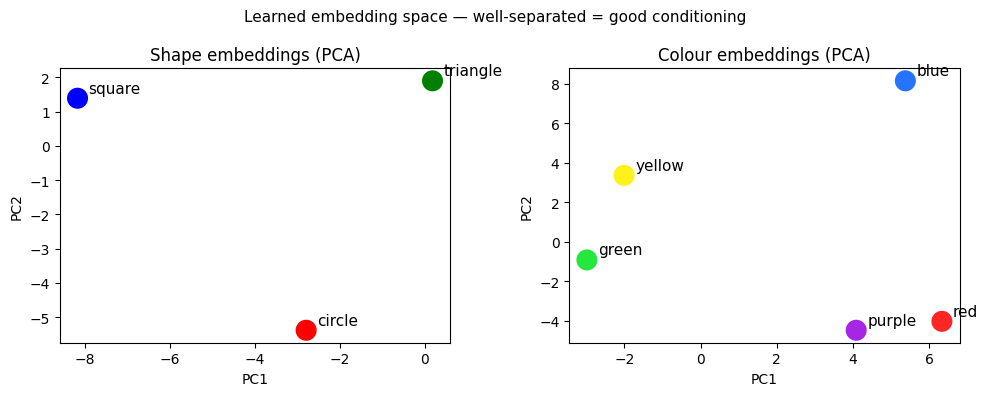

Shape cosine similarity matrix (should be low off-diagonal):
  circle  : 1.000  0.018  -0.011
  square  : 0.018  1.000  0.065
  triangle: -0.011  0.065  1.000


In [ ]:
from sklearn.decomposition import PCA
import warnings; warnings.filterwarnings('ignore')

core = model.module if num_gpus > 1 else model

with torch.no_grad():
    s_embs = core.shape_emb.weight[:N_SHAPES].cpu().numpy()   # (3, 128)
    c_embs = core.colour_emb.weight[:N_COLOURS].cpu().numpy() # (5, 128)

all_embs  = np.vstack([s_embs, c_embs])
pca       = PCA(n_components=2)
projected = pca.fit_transform(all_embs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Shape embeddings
ax = axes[0]
sp = projected[:N_SHAPES]
ax.scatter(sp[:,0], sp[:,1], s=200, c=['red','blue','green'], zorder=3)
for i, name in enumerate(SHAPES):
    ax.annotate(name, sp[i], textcoords='offset points', xytext=(8,4), fontsize=11)
ax.set_title('Shape embeddings (PCA)'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Colour embeddings
ax = axes[1]
cp = projected[N_SHAPES:]
colours_rgb = [[1,.15,.15],[.15,.45,1],[.15,.9,.25],[1,.95,.1],[.65,.15,.9]]
ax.scatter(cp[:,0], cp[:,1], s=200, c=colours_rgb, zorder=3)
for i, name in enumerate(COLOURS):
    ax.annotate(name, cp[i], textcoords='offset points', xytext=(8,4), fontsize=11)
ax.set_title('Colour embeddings (PCA)'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Learned embedding space — well-separated = good conditioning', fontsize=11)
plt.tight_layout(); plt.show()

# Print pairwise cosine similarities between shape embeddings
st = torch.tensor(s_embs)
st = st / st.norm(dim=1, keepdim=True)
sim = st @ st.T
print('Shape cosine similarity matrix (should be low off-diagonal):')
for i, s in enumerate(SHAPES):
    row = '  '.join(f'{sim[i,j].item():.3f}' for j in range(N_SHAPES))
    print(f'  {s:8s}: {row}')


## Summary

### Why v3 fixes shape confusion

| Problem in v2 | Fix in v3 |
|---|---|
| CLIP embeds "circle"/"square"/"triangle" similarly | Learned `nn.Embedding` — orthogonal by construction |
| 1,500 samples/class not enough | 5,000 samples/class |
| 50 epochs | 150 epochs with warmup + cosine LR |
| Single null vector for CFG | Independent null tokens for shape & colour |

### What the embedding plot shows
- Shape embeddings should be **well-separated** in PCA space
- Off-diagonal cosine similarities should be low (< 0.3)
- If the model sees "circle", it gets a unique, unambiguous vector — not a CLIP
  embedding that overlaps with "square"


In [ ]:
print('✓ Notebook complete')
print(f'  Device : {device}  ({num_gpus} GPU(s))')
print(f'  Dataset: {len(dataset):,} samples')
print(f'  Epochs : {EPOCHS}  final loss: {loss_history[-1]:.5f}')


✓ Notebook complete
  Device : cuda  (2 GPU(s))
  Dataset: 75,000 samples
  Epochs : 40  final loss: 0.00126
